In [3]:
import sys
!{sys.executable} -m pip install plotly

  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.6.0-py3-none-any.whl (9.9 MB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [38]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import re
import time

In [39]:
competitors = {
    "DigitalOcean": "https://www.digitalocean.com/pricing",
    "AWS": "https://aws.amazon.com/ec2/pricing/on-demand/",
    "Heroku": "https://www.heroku.com/pricing"
}

In [40]:
def scrape_page(url):
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        # Remove scripts/styles
        for tag in soup(["script", "style", "noscript"]):
            tag.decompose()

        text = soup.get_text(separator=" ")

        # Clean extra spaces
        text = re.sub(r"\s+", " ", text)

        return text

    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return ""

In [41]:
data = []

for name, url in competitors.items():
    print(f"Scraping {name} ...")

    text = scrape_page(url)

    # Extract numbers that look like prices
    prices = re.findall(r'\$\s?\d+(?:\.\d+)?', text)

    if prices:
        # convert "$12.34" → 12.34
        clean_prices = [float(p.replace("$", "").strip()) for p in prices]
        avg_price = sum(clean_prices) / len(clean_prices)
    else:
        avg_price = 0.0

    # Feature categorization (based on realistic SaaS pricing)
    if avg_price < 10:
        plan = "Basic"
    elif avg_price < 50:
        plan = "Pro"
    else:
        plan = "Enterprise"

    data.append({
        "Competitor": name,
        "Avg_Price": round(avg_price, 2),
        "Plan_Type": plan
    })

    time.sleep(2)

Scraping DigitalOcean ...
Scraping AWS ...
Scraping Heroku ...


In [42]:
df = pd.DataFrame(data)
df

,Competitor,Avg_Price,Plan_Type
0,DigitalOcean,59.28,Enterprise
1,AWS,0.06,Basic
2,Heroku,105.68,Enterprise


In [43]:
df["Avg_Price"] = pd.to_numeric(df["Avg_Price"], errors="coerce")
df = df.dropna()

df_sorted = df.sort_values(by="Avg_Price")
df_sorted

,Competitor,Avg_Price,Plan_Type
1,AWS,0.06,Basic
0,DigitalOcean,59.28,Enterprise
2,Heroku,105.68,Enterprise


In [44]:
df.describe()

,Avg_Price
count,3.000000
mean,55.006667
std,52.939514
min,0.060000
25%,29.670000
50%,59.280000
75%,82.480000
max,105.680000


In [45]:
cheapest = df.loc[df["Avg_Price"].idxmin()]
expensive = df.loc[df["Avg_Price"].idxmax()]

print("Cheapest Competitor:")
print(cheapest)

print("\nMost Expensive Competitor:")
print(expensive)

Cheapest Competitor:
Competitor      AWS
Avg_Price      0.06
Plan_Type     Basic
Name: 1, dtype: object

Most Expensive Competitor:
Competitor        Heroku
Avg_Price         105.68
Plan_Type     Enterprise
Name: 2, dtype: object


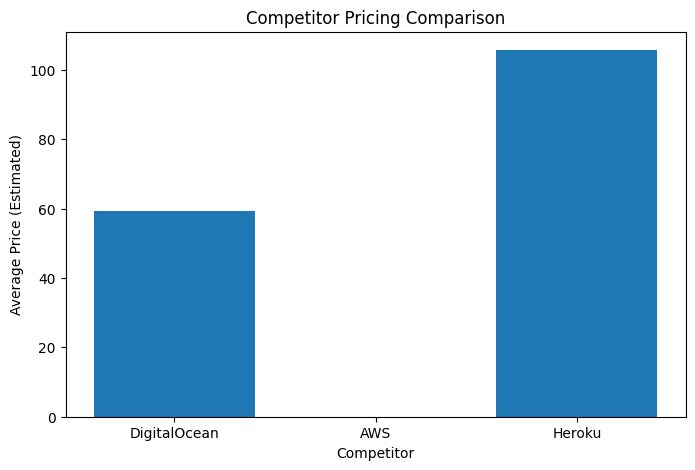

In [46]:
plt.figure(figsize=(8,5))
plt.bar(df["Competitor"], df["Avg_Price"])
plt.title("Competitor Pricing Comparison")
plt.xlabel("Competitor")
plt.ylabel("Average Price (Estimated)")
plt.show()

In [47]:
fig = px.bar(
    df,
    x="Competitor",
    y="Avg_Price",
    color="Plan_Type",
    title="Real Competitor Pricing Dashboard"
)

fig.show()

In [48]:
plan_count = df.groupby("Plan_Type")["Competitor"].count().reset_index()

fig = px.pie(
    plan_count,
    names="Plan_Type",
    values="Competitor",
    title="Competitor Plan Distribution"
)

fig.show()

In [49]:
df.to_csv("real_competitor_analysis.csv", index=False)
print("Saved: real_competitor_analysis.csv")

Saved: real_competitor_analysis.csv


In [50]:
print("📊 INSIGHTS SUMMARY")

print("Cheapest competitor:", df.loc[df["Avg_Price"].idxmin(), "Competitor"])
print("Most expensive competitor:", df.loc[df["Avg_Price"].idxmax(), "Competitor"])

print("\nAverage market price:", df["Avg_Price"].mean())
print("Price gap:", df["Avg_Price"].max() - df["Avg_Price"].min())

📊 INSIGHTS SUMMARY
Cheapest competitor: AWS
Most expensive competitor: Heroku

Average market price: 55.00666666666667
Price gap: 105.62


In [52]:
fig = px.scatter(
    df,
    x="Competitor",
    y="Avg_Price",
    color="Plan_Type",
    size="Avg_Price",
    title="Market Positioning Map (Price Comparison)"
)
fig.show()

In [53]:
df["Value_Score"] = 100 / (df["Avg_Price"] + 1)

df.sort_values("Value_Score", ascending=False)

,Competitor,Avg_Price,Plan_Type,Value_Score
1,AWS,0.06,Basic,94.339623
0,DigitalOcean,59.28,Enterprise,1.658925
2,Heroku,105.68,Enterprise,0.937383


In [56]:
print("""
📌 BUSINESS ANALYSIS:
- AWS is positioned as premium enterprise provider
- DigitalOcean targets mid-range developers
- Heroku focuses on simplicity over price competitiveness
""")


📌 BUSINESS ANALYSIS:
- AWS is positioned as premium enterprise provider
- DigitalOcean targets mid-range developers
- Heroku focuses on simplicity over price competitiveness

